## Lab 3 Intuición estadística V1

In [2]:
# Importa librerías para manejo de datos y visualización
import numpy as np            # Operaciones numéricas y generación de datos aleatorios
import pandas as pd           # Manipulación de dataframes/tablas de datos
import matplotlib.pyplot as plt  # Gráficas básicas en Python
import seaborn as sns         # Gráficas estadísticas con mejor estilo

# Importa funciones estadísticas
from scipy import stats       # Distribuciones y funciones estadísticas

# Importa modelos y utilidades de machine learning
from sklearn.linear_model import LinearRegression         # Regresión lineal
from sklearn.tree import DecisionTreeClassifier           # Árbol de decisión para clasificación
from sklearn.svm import SVC                              # Máquina de soporte vectorial (SVM)
from sklearn.model_selection import GridSearchCV, learning_curve, ShuffleSplit  # Validación y búsqueda de hiperparámetros
from sklearn.metrics import accuracy_score                # Métrica de exactitud

# Configura el estilo de los gráficos
sns.set_theme(style="whitegrid")

# Fija la semilla para reproducibilidad de los resultados aleatorios
np.random.seed(42)

## Intuición estadística: modelos de *machine learning*

**1.** Generar dos distribuciones de probabilidad centradas en 5.0, 7.5 con desviación estándar de 2.5 y 1.5 respectivamente. Realizar un gráfico de ambas distribuciones de probabilidad.

  **a)**. Emplear el objeto [stats.norm](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.norm.html) y el método *Probability density function* (pdf)

  **b)** Realizar un gráfico de ambas distribuciones

In [3]:
# Calcula la(s) frontera(s) analítica(s) (puntos de corte) entre dos normales univariadas
def frontera_bayesiana(media1, desv1, media2, desv2):
    a = 1 / (2 * desv1**2) - 1 / (2 * desv2**2)
    b = -media1 / (desv1**2) + media2 / (desv2**2)
    c = media1**2 / (2 * desv1**2) - media2**2 / (2 * desv2**2) - np.log(desv2 / desv1)
    raices = np.roots([a, b, c])
    raices = np.sort(raices[np.isreal(raices)].real)
    return raices

# Genera datos de entrenamiento y test a partir de dos distribuciones normales
def crear_datos(media1=5.0, desv1=2.5, media2=7.5, desv2=1.5,
                n_train_por_clase=100, n_test_por_clase=25, seed=42):
    rng = np.random.default_rng(seed)
    dist1 = stats.norm(loc=media1, scale=desv1)
    dist2 = stats.norm(loc=media2, scale=desv2)
    x1_train = dist1.rvs(size=n_train_por_clase, random_state=rng)
    x2_train = dist2.rvs(size=n_train_por_clase, random_state=rng)
    x1_test = dist1.rvs(size=n_test_por_clase, random_state=rng)
    x2_test = dist2.rvs(size=n_test_por_clase, random_state=rng)
    X_train = np.concatenate([x1_train, x2_train])
    y_train = np.concatenate([np.zeros(n_train_por_clase, dtype=int),
                              np.ones(n_train_por_clase, dtype=int)])
    X_test = np.concatenate([x1_test, x2_test])
    y_test = np.concatenate([np.zeros(n_test_por_clase, dtype=int),
                             np.ones(n_test_por_clase, dtype=int)])
    idx_train = rng.permutation(len(X_train))
    idx_test = rng.permutation(len(X_test))
    df_train = pd.DataFrame({
        "Y": y_train[idx_train],
        "X_1": X_train[idx_train]
    }).reset_index(drop=True)
    df_test = pd.DataFrame({
        "Y": y_test[idx_test],
        "X_1": X_test[idx_test]
    }).reset_index(drop=True)
    X_train = df_train[["X_1"]].values
    y_train = df_train["Y"].values
    X_test = df_test[["X_1"]].values
    y_test = df_test["Y"].values
    return dist1, dist2, df_train, df_test, X_train, y_train, X_test, y_test

# Grafica las funciones de densidad de dos normales y sus fronteras analíticas
def plot_pdf_distribuciones(dist1, dist2, media1, desv1, media2, desv2):
    x = np.linspace(media1 - 4 * desv1, media2 + 4 * desv2, 600)
    fronteras = frontera_bayesiana(media1, desv1, media2, desv2)
    plt.figure(figsize=(10, 5))
    plt.plot(x, dist1.pdf(x), lw=2, label=f"N({media1}, {desv1})")
    plt.plot(x, dist2.pdf(x), lw=2, label=f"N({media2}, {desv2})")
    for r in fronteras:
        plt.axvline(r, color="k", ls="--", alpha=0.7)
    plt.title("Distribuciones de probabilidad")
    plt.xlabel("x")
    plt.ylabel("densidad")
    plt.legend()
    plt.tight_layout()
    plt.show()

# Grafica histogramas superpuestos de las muestras de entrenamiento por clase
def plot_muestras(df_train):
    plt.figure(figsize=(10, 5))
    clase0 = df_train[df_train["Y"] == 0]["X_1"]
    clase1 = df_train[df_train["Y"] == 1]["X_1"]
    plt.hist(clase0, bins=20, density=True, alpha=0.45, label="Clase 0")
    plt.hist(clase1, bins=20, density=True, alpha=0.45, label="Clase 1")
    plt.title("Muestras de entrenamiento superpuestas")
    plt.xlabel("X_1")
    plt.ylabel("densidad")
    plt.legend()
    plt.tight_layout()
    plt.show()

# Entrena un modelo, muestra su score y accuracy (si es regresión lineal)
def reportar_modelo(modelo, X_train, y_train, X_test, y_test, nombre):
    modelo.fit(X_train, y_train)
    score_train = modelo.score(X_train, y_train)
    score_test = modelo.score(X_test, y_test)
    print(nombre)
    print("  score entrenamiento:", score_train)
    print("  score test:", score_test)
    if isinstance(modelo, LinearRegression):
        pred_train = (modelo.predict(X_train) >= 0.5).astype(int)
        pred_test = (modelo.predict(X_test) >= 0.5).astype(int)
        print("  accuracy entrenamiento con umbral 0.5:", accuracy_score(y_train, pred_train))
        print("  accuracy test con umbral 0.5:", accuracy_score(y_test, pred_test))
    print()

# Grafica la curva de aprendizaje de un estimador
def plot_learning_curve(estimator, title, X, y, ylim=None, cv=None, n_jobs=None,
                        train_sizes=np.linspace(0.1, 1.0, 5)):
    plt.figure(figsize=(10, 6))
    plt.title(title)
    if ylim is not None:
        plt.ylim(*ylim)
    plt.xlabel("Número de ejemplos de entrenamiento")
    plt.ylabel("Puntaje")
    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y,
        cv=cv,
        n_jobs=n_jobs,
        train_sizes=train_sizes,
        shuffle=True,
        random_state=42
    )
    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)
    plt.grid(True, alpha=0.3)
    plt.fill_between(train_sizes,
                     train_scores_mean - train_scores_std,
                     train_scores_mean + train_scores_std,
                     alpha=0.15, color="tab:blue")
    plt.fill_between(train_sizes,
                     test_scores_mean - test_scores_std,
                     test_scores_mean + test_scores_std,
                     alpha=0.15, color="tab:orange")
    plt.plot(train_sizes, train_scores_mean, "o-", color="tab:blue", label="Entrenamiento")
    plt.plot(train_sizes, test_scores_mean, "o-", color="tab:orange", label="Validación")
    plt.legend(loc="best")
    plt.tight_layout()
    plt.show()


Frontera analítica exacta:
[ 5.8921321 11.9203679]


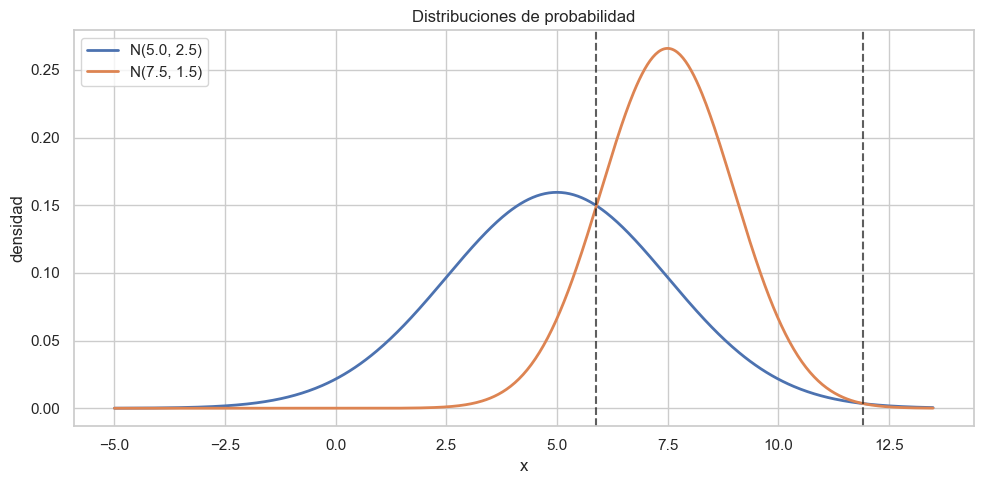

In [4]:
# Definición de las distribuciones normales
media1, desv1 = 5.0, 2.5
media2, desv2 = 7.5, 1.5

dist1 = stats.norm(loc=media1, scale=desv1)
dist2 = stats.norm(loc=media2, scale=desv2)

# Cálculo y visualización de la frontera analítica
print("\n" + "=" * 80)
print("Frontera analítica exacta:")
print("=" * 80)
print(frontera_bayesiana(media1, desv1, media2, desv2))

# Gráfica ambas distribuciones y la(s) frontera(s)
plot_pdf_distribuciones(dist1, dist2, media1, desv1, media2, desv2)

**2.** ¿Qué frontera analítica puede separar los datos? Determine una expresión analítica en este caso.

La frontera analítica que separa los datos de dos distribuciones normales univariadas con medias y desviaciones estándar distintas se obtiene igualando sus funciones de densidad:

$$
f_1(x) = f_2(x)
$$

Teniendo dos normales $N(\mu_1, \sigma_1)$ y $N(\mu_2, \sigma_2)$, la ecuación es de la forma:

$$
\frac{1}{\sqrt{2\pi}\sigma_1} \exp\left(-\frac{(x-\mu_1)^2}{2\sigma_1^2}\right) = \frac{1}{\sqrt{2\pi}\sigma_2} \exp\left(-\frac{(x-\mu_2)^2}{2\sigma_2^2}\right)
$$

Tomando su logaritmo y simplificando términos:

$$
-\frac{(x-\mu_1)^2}{2\sigma_1^2} - \ln \sigma_1 = -\frac{(x-\mu_2)^2}{2\sigma_2^2} - \ln \sigma_2
$$

$$
\Rightarrow \frac{(x-\mu_2)^2}{2\sigma_2^2} - \frac{(x-\mu_1)^2}{2\sigma_1^2} = \ln\left(\frac{\sigma_2}{\sigma_1}\right)
$$

Esto es una ecuación cuadrática en $x$. Resolviendo para los parámetros del ejercicio ($\mu_1=5.0$, $\sigma_1=2.5$, $\mu_2=7.5$, $\sigma_2=1.5$):

$$
\frac{(x-7.5)^2}{2 \cdot 1.5^2} - \frac{(x-5.0)^2}{2 \cdot 2.5^2} = \ln\left(\frac{1.5}{2.5}\right)
$$

La(s) solución(es) de esta ecuación cuadrática dan la(s) frontera(s) analítica(s) que separan los datos.

**3.** Empleando el método *Random variates* (rvs), genere 100 muestras aleatorias para cada distribución; estos serán los datos de entrenamiento.

In [6]:
# Generación de datos de entrenamiento y test

dist1, dist2, df_train, df_test, X_train, y_train, X_test, y_test = crear_datos(media1=5.0, desv1=2.5, media2=7.5, desv2=1.5, n_train_por_clase=100, n_test_por_clase=25, seed=42)

**4.** Realice un gráfico en el que pueda superponer ambas distribuciones; estas 200 muestras serán las características (*features*) de nuestro data frame. Para cada característica tendremos una etiqueta (*labels*) correspondiente a 0 ó 1.

**5.** Con los datos anteriores construya un `DataFrame` con los *features* y *labels* de la siguiente forma:

 |Y (*labels*)| X_1 (*feature*)|
 |---|---|
 |$Y^{1}$| $X_1^{1}$|
 |$Y^{2}$| $X_1^{2}$|
 |.| .|
 |.| .|
 |.| .|
 |$Y^{m}$| $X_1^{m}$|

- Se sugiere emplear las claves `Y`, `X` para los labels y features respectivamente.
- $Y^{1}, Y^{2}, ... , Y^{m}$ son los labels de entrenamiento.
- $X_1^{1}, X_1^{2}, ... , X_1^{m}$ es el conjunto de datos de entrenamiento asociado a la característica 1 en el entrenamiento m.
- Este dataframe será el dataset de entrenamiento; para los datos de test construiremos 50 variables aleatorias.

In [7]:
# Visualización y estructura del DataFrame de entrenamiento
print("\n" + "=" * 80)
print("df_train:")
print("=" * 80)
display(df_train.head())


df_train:


,Y,X_1
0,0,4.119666
1,0,4.209394
2,0,4.045655
3,1,10.151895
4,0,6.944480


**6.** Construye un segundo data frame con 50 datos de test, asociados a las muestras de las dos distribuciones; estos serán los datos de test empleados para validar los algoritmos de clasificación `df_test` con claves `Y`, `X_1`.


df_test:


,Y,X_1
0,1,9.308780
1,0,5.441433
2,0,1.952967
3,0,6.609847
4,0,1.684018


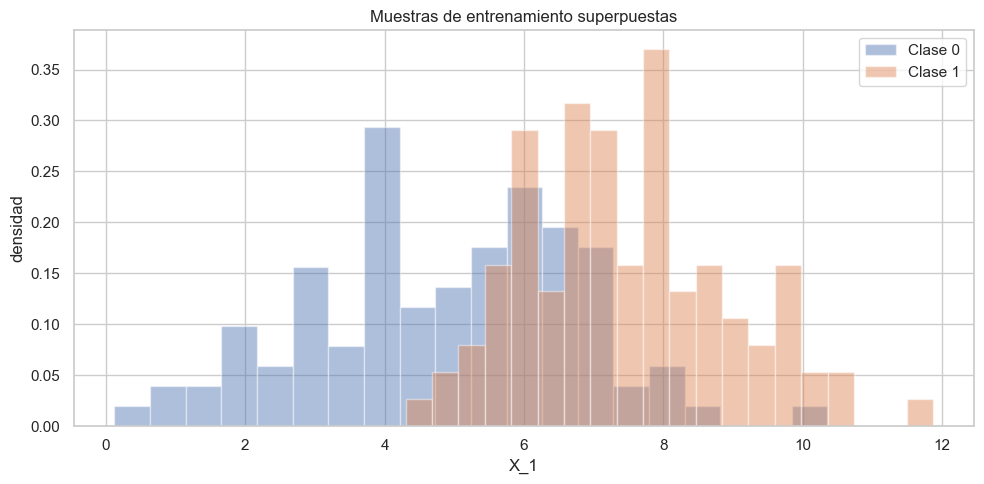

In [8]:
#Visualización y estructura del DataFrame de test
print("\n" + "=" * 80)
print("df_test:")
print("=" * 80)
display(df_test.head())
print("=" * 80)

# Gráfica las muestras de entrenamiento (Punto 4)
plot_muestras(df_train)

In [9]:
modelos = {
    "LinearRegression": LinearRegression(),
    "DecisionTreeClassifier(max_depth=3)": DecisionTreeClassifier(max_depth=3, random_state=42),
    "SVC(kernel='linear', C=0.025)": SVC(kernel="linear", C=0.025)
}

for nombre, modelo in modelos.items():
    reportar_modelo(modelo, X_train, y_train, X_test, y_test, nombre)

LinearRegression
  score entrenamiento: 0.3671531153198879
  score test: 0.2518087919404651
  accuracy entrenamiento con umbral 0.5: 0.74
  accuracy test con umbral 0.5: 0.72

DecisionTreeClassifier(max_depth=3)
  score entrenamiento: 0.78
  score test: 0.74

SVC(kernel='linear', C=0.025)
  score entrenamiento: 0.745
  score test: 0.72



In [10]:
param_grid = {
    "max_depth": [3, 4, 5, 6, 7, 8],
    "criterion": ["gini", "entropy"]
}

clf = DecisionTreeClassifier(random_state=42)

CV_clf = GridSearchCV(
    estimator=clf,
    param_grid=param_grid,
    cv=10,
    n_jobs=-1
)

CV_clf.fit(X_train, y_train)

print("Mejores hiperparámetros:")
print(CV_clf.best_params_)
print("Mejor score de validación cruzada:")
print(CV_clf.best_score_)
print("Score en test:")
print(CV_clf.score(X_test, y_test))

Mejores hiperparámetros:
{'criterion': 'entropy', 'max_depth': 3}
Mejor score de validación cruzada:
0.72
Score en test:
0.74


c:\Users\Biohealthy\Desktop\Universidad\Semestre 2026-1\Computacional_2\venv\Lib\site-packages\numpy\ma\core.py:2892: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


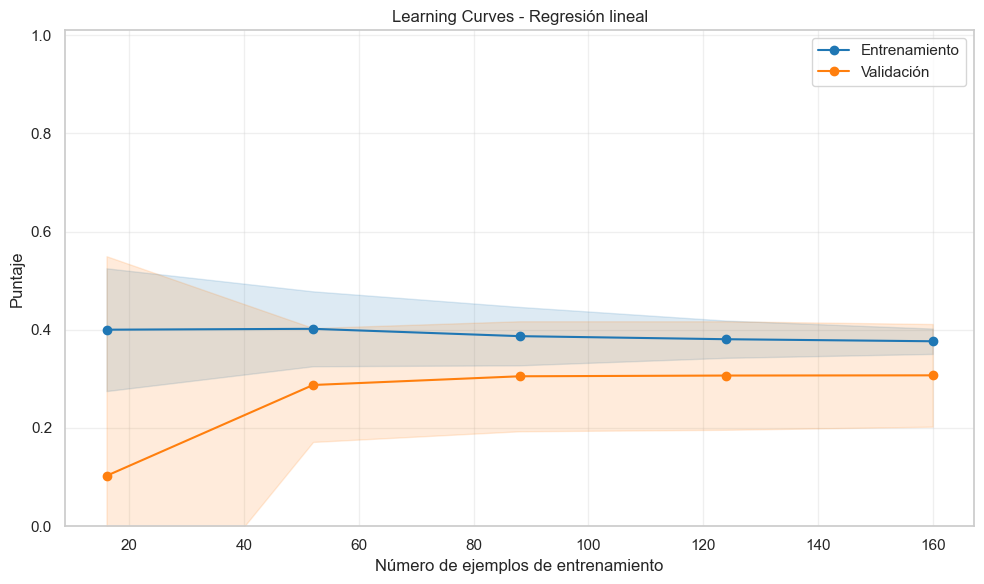

In [11]:
regr = LinearRegression()
cv = ShuffleSplit(n_splits=10, test_size=0.2, random_state=42)

plot_learning_curve(
    regr,
    "Learning Curves - Regresión lineal",
    X_train,
    y_train,
    ylim=(0.0, 1.01),
    cv=cv,
    n_jobs=-1
)

30 datos de entrenamiento | media1=7.5, media2=10, desv1=1, desv2=1
Fronteras analíticas: [8.75]


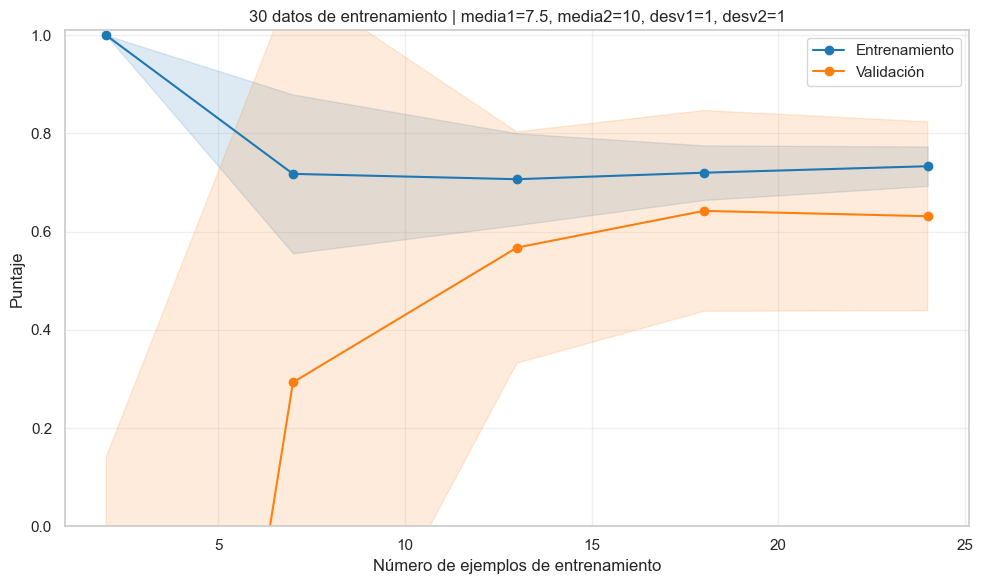

100 datos de entrenamiento | media1=7.5, media2=10, desv1=1, desv2=1
Fronteras analíticas: [8.75]


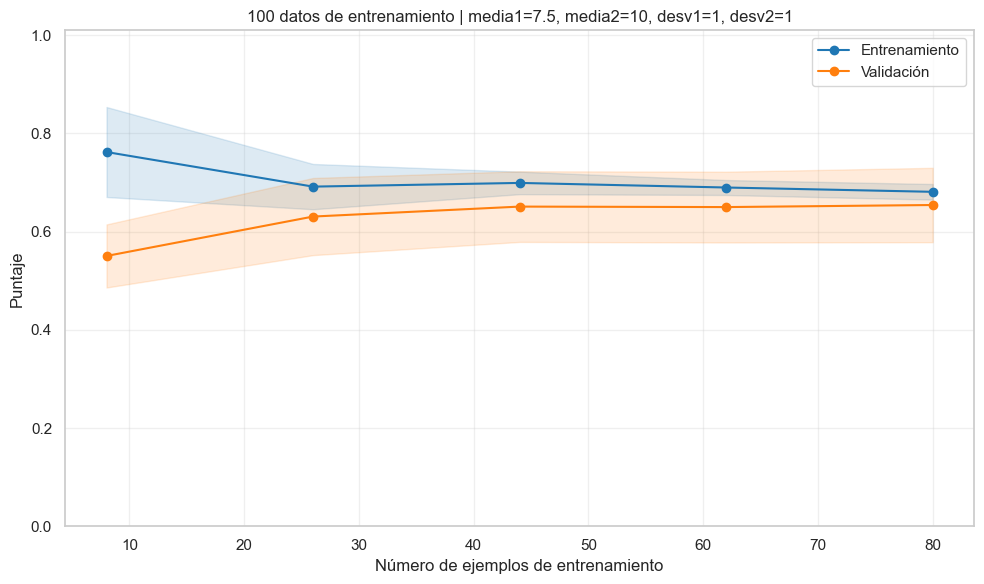

200 datos de entrenamiento | media1=7.5, media2=7.0, desv1=2, desv2=2
Fronteras analíticas: [7.25]


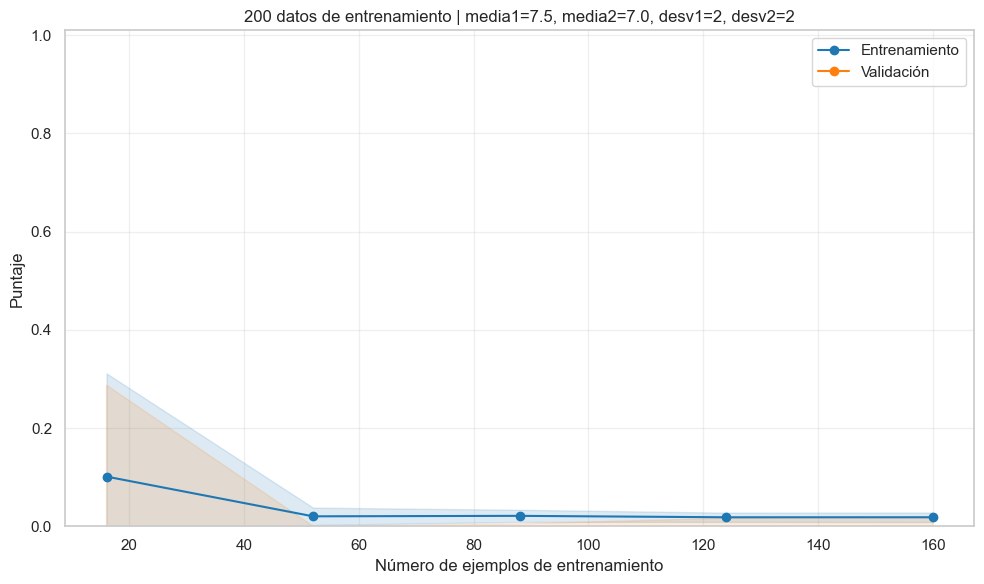

200 datos de entrenamiento | media1=7.5, media2=7.0, desv1=0.5, desv2=0.5
Fronteras analíticas: [7.25]


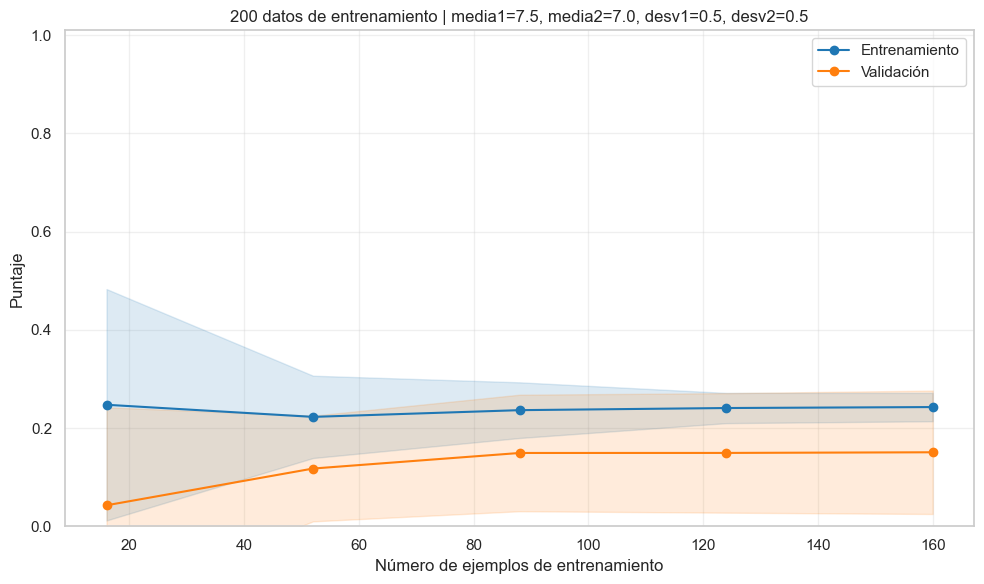

In [12]:
escenarios = [
    {
        "nombre": "30 datos de entrenamiento | media1=7.5, media2=10, desv1=1, desv2=1",
        "media1": 7.5,
        "media2": 10.0,
        "desv1": 1.0,
        "desv2": 1.0,
        "n_train_por_clase": 15
    },
    {
        "nombre": "100 datos de entrenamiento | media1=7.5, media2=10, desv1=1, desv2=1",
        "media1": 7.5,
        "media2": 10.0,
        "desv1": 1.0,
        "desv2": 1.0,
        "n_train_por_clase": 50
    },
    {
        "nombre": "200 datos de entrenamiento | media1=7.5, media2=7.0, desv1=2, desv2=2",
        "media1": 7.5,
        "media2": 7.0,
        "desv1": 2.0,
        "desv2": 2.0,
        "n_train_por_clase": 100
    },
    {
        "nombre": "200 datos de entrenamiento | media1=7.5, media2=7.0, desv1=0.5, desv2=0.5",
        "media1": 7.5,
        "media2": 7.0,
        "desv1": 0.5,
        "desv2": 0.5,
        "n_train_por_clase": 100
    }
]

for esc in escenarios:
    dist1_e, dist2_e, df_train_e, df_test_e, X_train_e, y_train_e, X_test_e, y_test_e = crear_datos(
        media1=esc["media1"],
        desv1=esc["desv1"],
        media2=esc["media2"],
        desv2=esc["desv2"],
        n_train_por_clase=esc["n_train_por_clase"],
        n_test_por_clase=25,
        seed=42
    )

    print(esc["nombre"])
    print("Fronteras analíticas:", frontera_bayesiana(esc["media1"], esc["desv1"], esc["media2"], esc["desv2"]))

    plot_learning_curve(
        LinearRegression(),
        esc["nombre"],
        X_train_e,
        y_train_e,
        ylim=(0.0, 1.01),
        cv=cv,
        n_jobs=-1
    )